<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml03_train_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier  # KNN 분류기 머신러닝 모델
from sklearn.model_selection import train_test_split  # 훈련 셋/테스트 셋 분리 함수
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # 평가지표 함수들
from sklearn.metrics import classification_report, confusion_matrix  # 평가지표 내용 출력
from sklearn.preprocessing import StandardScaler  # 표준화 특성 스케일 변환기

# 데이터 준비

In [2]:
file_path = 'https://bit.ly/fish_csv_data'
# https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv

In [3]:
fish = pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
fish.tail()

,Species,Weight,Length,Diagonal,Height,Width
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,15.0,16.2,2.9322,1.8792


In [6]:
pd.set_option('display.max_rows', 10)

In [7]:
# Bream(도미) vs Smelt(빙어) 분류 문제
df = fish[fish.Species.isin(['Bream', 'Smelt'])]
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [10]:
# 특성(features) 배열 - 2차원
x = df[['Weight', 'Length']].values

In [11]:
x[:5]

array([[242. ,  25.4],
       [290. ,  26.3],
       [340. ,  26.5],
       [363. ,  29. ],
       [430. ,  29. ]])

In [12]:
x[-5:]

array([[12.2, 12.2],
       [13.4, 12.4],
       [12.2, 13. ],
       [19.7, 14.3],
       [19.9, 15. ]])

In [13]:
x.shape  #> (n_samples, n_features)

(49, 2)

In [14]:
# 타겟 배열 - 1차원 배열
y = df.Species.values

In [15]:
y

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

# 훈련 셋 vs 테스트 셋 분리

*  머신러닝(Machine Learning): 컴퓨터가 데이터를 학습해서 예측.
*  훈련(training), 학습(learning): 머신러닝 알고리즘(모델)에게 특성 데이터(와 레이블)을 제공.
*  평가(evaluation): 학습된 데이터와 학습되지 않은 데이터를 얼마나 잘 예측하는 지를 점수화.
*  훈련 셋: 머신러닝 모델에게 제공하는 특성 데이터(와 레이블)
*  테스트 셋: 평가를 위해서만 남겨두는 특성 데이터(와 레이블)
*  훈련 셋과 테스트 셋으로 분리하는 방법
    *   순차 추출(sequential sampling)
    *   임의 추출(random sampling)
    *   층화 추출(stratified sampling)

## 순차 추출(sequential sampling)

In [17]:
num_trains = 35  # 훈련 셋 샘플 개수(전체 샘플의 약 70%)

In [19]:
# 특성 배열을 훈련 셋, 테스트 셋으로 분리
x_train = x[:num_trains]  # 훈련 셋
x_test = x[num_trains:]  # 테스트 셋

In [20]:
# 레이블(타겟 배열) 훈련 레이블, 테스트 레이블로 분리
y_train = y[:num_trains]  # 훈련 레이블
y_test = y[num_trains:]  # 테스트 레이블

In [21]:
x_train.shape  #> (35, 2) = (n_samples, n_features)

(35, 2)

In [22]:
x_test.shape  #> (14, 2)

(14, 2)

In [23]:
y_train.shape  #> (35,) = (n_samples,)

(35,)

In [24]:
y_test.shape  #> (14,)

(14,)

In [25]:
# KNN 분류 모델 생성
knn = KNeighborsClassifier()

In [26]:
# KNN 모델을 훈련 셋(과 훈련 레이블)로 훈련
knn.fit(X=x_train, y=y_train)

KNeighborsClassifier()

In [27]:
# 학습된 데이터(훈련 셋)으로 평가
train_acc = knn.score(X=x_train, y=y_train)
train_acc

1.0

In [28]:
# 학습되지 않은 데이터(테스트 셋)에서 평가
test_acc = knn.score(X=x_test, y=y_test)
test_acc

0.0

In [29]:
y_train

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [30]:
y_test

array(['Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

데이터가 어떤 기준을 가지고 정렬되어 있는 경우, 순차 추출을 하게 되면 한번도 훈련이 되지 못하는 레이블들이 있을 수 있기 때문에 순차 추출은 사용하면 안됨!

데이터들이 임의로 섞여 있는 경우에는 순차 추출을 사용하기도 함.

## 임의 추출(random sampling)

In [32]:
indices = np.arange(49)
print(indices)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


In [33]:
np.random.seed(42)
np.random.shuffle(indices)  # 아규먼트로 전달된 배열의 값들을 무작위로 섞어줌.
print(indices)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [34]:
train_indices = indices[:num_trains]  # 훈련 셋을 추출(sampling)하기 위한 인덱스들
test_indices = indices[num_trains:]  # 테스트 셋을 추출하기 위한 인덱스들

In [37]:
x_train = x[train_indices]  # 훈련 셋
x_test = x[test_indices]  # 테스트 셋

In [38]:
y_train = y[train_indices]  # 훈련 레이블
y_test = y[test_indices]  # 테스트 레이블

In [39]:
y_train

array(['Bream', 'Smelt', 'Smelt', 'Smelt', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Smelt', 'Smelt', 'Smelt', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt', 'Bream',
       'Bream', 'Bream', 'Bream', 'Smelt', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [40]:
y_test

array(['Smelt', 'Smelt', 'Bream', 'Smelt', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Bream', 'Bream', 'Smelt', 'Bream', 'Bream', 'Smelt'],
      dtype=object)

In [41]:
# KNN 생성
knn = KNeighborsClassifier()

In [42]:
# KNN 훈련
knn.fit(X=x_train, y=y_train)

KNeighborsClassifier()

In [43]:
# 학습된 데이터에서 정확도
knn.score(X=x_train, y=y_train)

1.0

In [44]:
# 학습되지 않은 데이터에서 정확도
knn.score(X=x_test, y=y_test)

1.0

In [47]:
# 훈련 셋(레이블)에서 도미 vs 빙어 비율
pd.Series(y_train).value_counts(normalize=True)

,proportion
Bream,0.771429
Smelt,0.228571


In [48]:
# 테스트 셋(레이블)에서 도미 vs 빙어 비율
pd.Series(y_test).value_counts(normalize=True)

,proportion
Bream,0.571429
Smelt,0.428571


임의 추출(random sampling)의 단점은 훈련 셋과 테스트 셋에서 각 클래스(도미 vs 빙어)들의 비율이 비슷하지 않을 수도 있다는 점.

이런 경우에는 머신러닝 모델의 성능이 안 좋아질 수 있음(테스트 셋에서의 정확도가 떨어질 수 있음).

이런 단점을 보완하는 샘플링 방식이 층화 추출(stratified sampling).

## 층화 추출(stratified sampling)

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    train_size=35,
                                                    random_state=42,
                                                    stratify=y)

`train_test_split()` 함수의 파라미터:

*   가변길이 인수(`*array`): 훈련 셋 vs 테스트 셋으로 나눌 배열(들).
*   `test_size`: 테스트 셋의 샘플 개수(0 이상의 정수) 또는 비율(0.0 ~ 1.0 사이의 실수).
    *   test_size 파라미터를 설정하면 train_size는 자동으로 결정됨.
*   `train_size`: 훈련 셋의 샘플 개수 또는 비율.
    *   train_size를 설정하면 test_size는 자동으로 결정됨.
*   `random_state`: 난수를 생성할 때 사용하는 seed. random sampling을 사용할 때만 사용됨.
*   `shuffle`: 샘플들을 무작위로 섞을 지 여부를 설정. 기본값은 True. random sampling이 기본 동작.
*   `stratify`: 층화 추출(stratified sampling)을 하기 위해서 각 클래스들의 비율을 알 수 있는 1차원 배열. 기본값은 None. 층화 추출을 하지 않는 것이 기본 동작.


In [50]:
x_train.shape

(35, 2)

In [51]:
x_test.shape

(14, 2)

In [52]:
y_train.shape

(35,)

In [53]:
y_test.shape

(14,)

In [58]:
pd.Series(y).value_counts(normalize=True)  # 전체 타겟 배열에서 도미 vs 빙어 비율

,proportion
Bream,0.714286
Smelt,0.285714


In [56]:
pd.Series(y_train).value_counts(normalize=True)  # 훈련 레이블에서 도미 vs 빙어 비율

,proportion
Bream,0.714286
Smelt,0.285714


In [59]:
pd.Series(y_test).value_counts(normalize=True)  # 테스트 레이블에서 도미 vs 빙어 비율

,proportion
Bream,0.714286
Smelt,0.285714


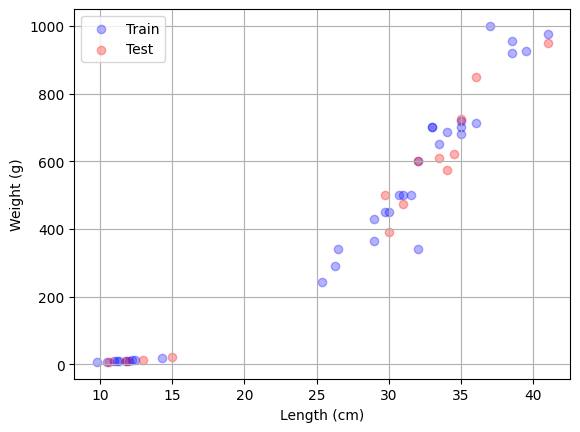

In [68]:
# 훈련 셋(x_train) 산점도
plt.scatter(x_train[:, 1], x_train[:, 0], alpha=0.3, color='blue', label='Train')

# 테스트 셋(x_test) 산점도
plt.scatter(x_test[:, 1], x_test[:, 0], alpha=0.3, color='red', label='Test')

plt.legend()
plt.xlabel('Length (cm)')
plt.ylabel('Weight (g)')
plt.grid()
plt.show()

In [69]:
knn = KNeighborsClassifier()  # KNN 모델 생성

In [70]:
knn.fit(X=x_train, y=y_train)  # KNN 모델 훈련

KNeighborsClassifier()

In [71]:
# 학습된 데이터(훈련 셋)에서의 정확도
knn.score(X=x_train, y=y_train)

1.0

In [72]:
# 학습되지 않은 데이터(테스트 셋)에서의 정확도
knn.score(X=x_test, y=y_test)

1.0

# 분류 평가 지표